In [50]:
import os
#['100307', '102816', '133019', '149741', '153732', '154532']

sjnr = '100307'#'154532'#'153732'#'149741'#''102816'

if os.path.exists(f"/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/Diffusion_7T"):
    diffusion_path = f"/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/Diffusion_7T"
else:
    diffusion_path = f"/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/Diffusion"

In [51]:
%matplotlib widget

Loading DTI data from /Users/marcoaqil/Desktop/miami_mac/Downloads/100307/Diffusion...


/var/folders/cw/1v50jvlx7wzfdpd05sq5s9_w0000gn/T/ipykernel_16412/2094746878.py:23: UserWarning: Pass ['bvecs'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  gtab = gradient_table(bvals, bvecs)


Loading T1w image...


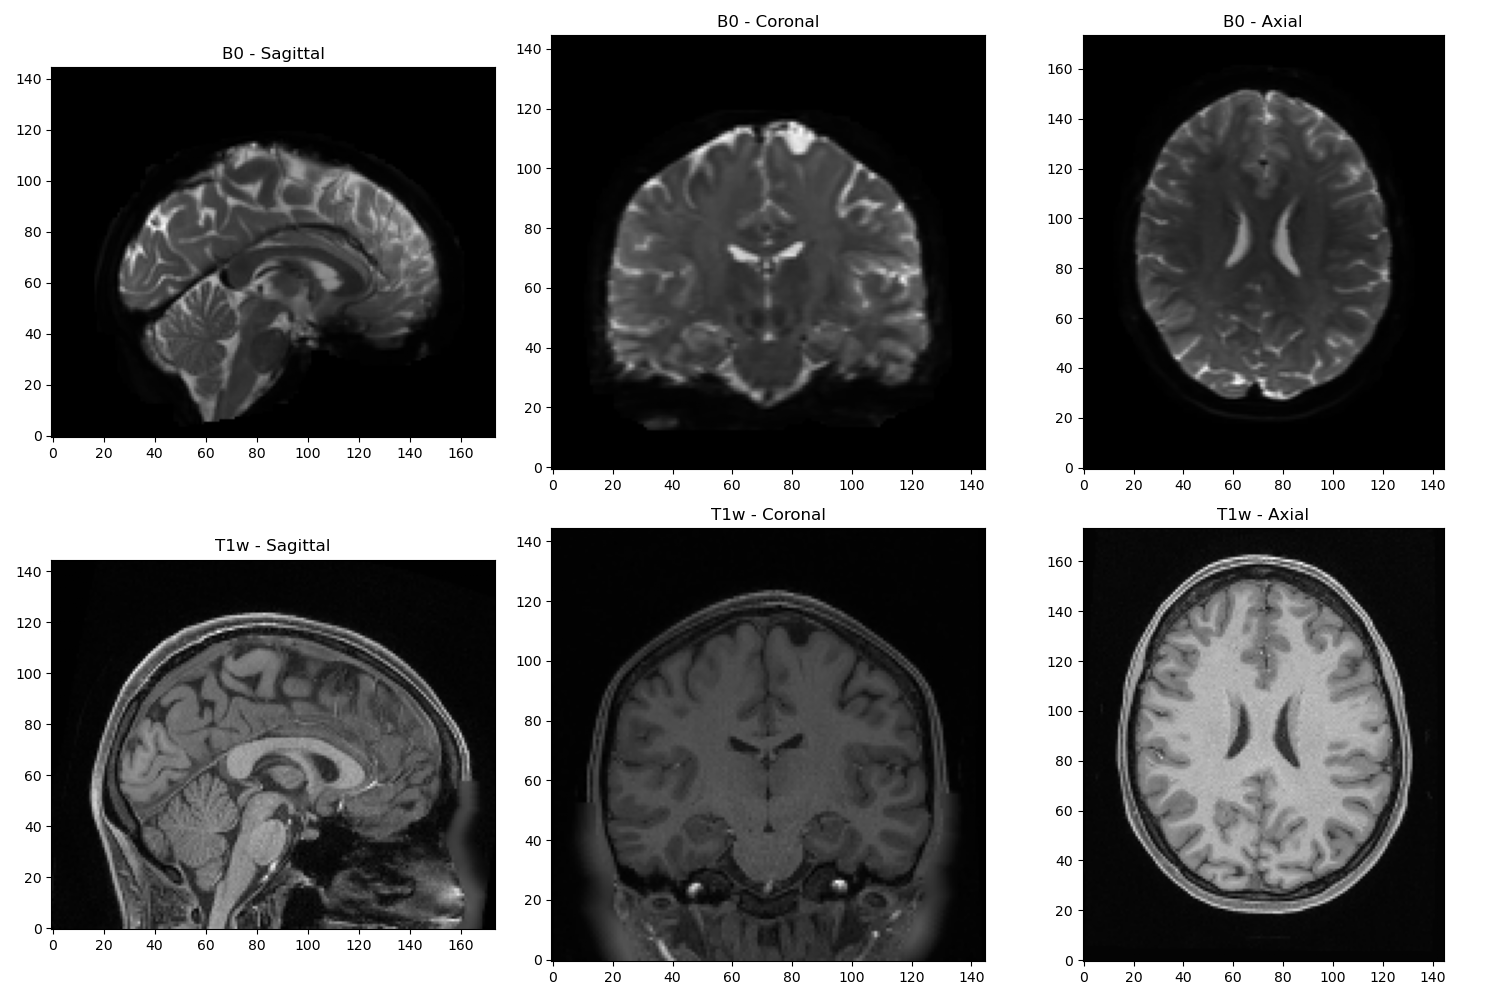

B0 shape: (145, 174, 145), affine:
[[  -1.25    0.      0.     90.  ]
 [   0.      1.25    0.   -126.  ]
 [   0.      0.      1.25  -72.  ]
 [   0.      0.      0.      1.  ]]

T1w shape: (145, 174, 145), affine:
[[  -1.25    0.      0.     90.  ]
 [   0.      1.25    0.   -126.  ]
 [   0.      0.      1.25  -72.  ]
 [   0.      0.      0.      1.  ]]


In [52]:
import numpy as np

import nibabel as nib
from dipy.io.gradients import read_bvals_bvecs
from dipy.core.gradients import gradient_table
from dipy.reconst.dti import TensorModel
from dipy.align.imaffine import (AffineMap, MutualInformationMetric, 
                                  AffineRegistration)
from dipy.align.transforms import (TranslationTransform3D, RigidTransform3D, 
                                     AffineTransform3D)


# ==================== LOAD DTI DATA ====================


print(f"Loading DTI data from {diffusion_path}...")
img = nib.load(f"{diffusion_path}/data.nii.gz")
data = img.get_fdata().astype(np.float32) 
dti_affine = img.affine
inv_dti_affine = np.linalg.inv(dti_affine)

bvals, bvecs = read_bvals_bvecs(f"{diffusion_path}/bvals", f"{diffusion_path}/bvecs")
gtab = gradient_table(bvals, bvecs)

mask = nib.load(f"{diffusion_path}/nodif_brain_mask.nii.gz").get_fdata() > 0

# Get b0 image (reference for registration)
b0_indices = np.where(bvals < 70)[0]
b0_image = np.nanmean(data[..., b0_indices], axis=-1)


# ==================== LOAD T1w IMAGE ====================
print("Loading T1w image...")
try:
    t1w_img = nib.load(f"/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/T1w/T1w_acpc_dc_restore_1.05.nii.gz")
except:
    t1w_img = nib.load(f"/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/T1w/T1w_acpc_dc_restore_1.25.nii.gz")

t1w_data = t1w_img.get_fdata().astype(np.float32)
t1w_affine = t1w_img.affine

# ========== PRE-REGISTRATION CHECK ==========
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# B0 (DTI reference) - three orthogonal slices
mid_x, mid_y, mid_z = [s//2 for s in b0_image.shape]
axes[0,0].imshow(b0_image[mid_x, :, :].T, cmap='gray', origin='lower')
axes[0,0].set_title('B0 - Sagittal')
axes[0,1].imshow(b0_image[:, mid_y, :].T, cmap='gray', origin='lower')
axes[0,1].set_title('B0 - Coronal')
axes[0,2].imshow(b0_image[:, :, mid_z].T, cmap='gray', origin='lower')
axes[0,2].set_title('B0 - Axial')

# T1w - three orthogonal slices
mid_x_t1, mid_y_t1, mid_z_t1 = [s//2 for s in t1w_data.shape]
axes[1,0].imshow(t1w_data[mid_x_t1, :, :].T, cmap='gray', origin='lower')
axes[1,0].set_title('T1w - Sagittal')
axes[1,1].imshow(t1w_data[:, mid_y_t1, :].T, cmap='gray', origin='lower')
axes[1,1].set_title('T1w - Coronal')
axes[1,2].imshow(t1w_data[:, :, mid_z_t1].T, cmap='gray', origin='lower')
axes[1,2].set_title('T1w - Axial')

plt.tight_layout()
plt.show()

print(f"B0 shape: {b0_image.shape}, affine:\n{dti_affine}")
print(f"\nT1w shape: {t1w_data.shape}, affine:\n{t1w_affine}")


*** SKIPPING REGISTRATION - Using identity transform ***
Assuming T1w and DTI are already aligned...
Identity transform created.


/var/folders/cw/1v50jvlx7wzfdpd05sq5s9_w0000gn/T/ipykernel_16412/730711257.py:11: UserWarning: Pass ['domain_grid_shape', 'domain_grid2world', 'codomain_grid_shape', 'codomain_grid2world'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  affine_registration = AffineMap(identity_matrix,


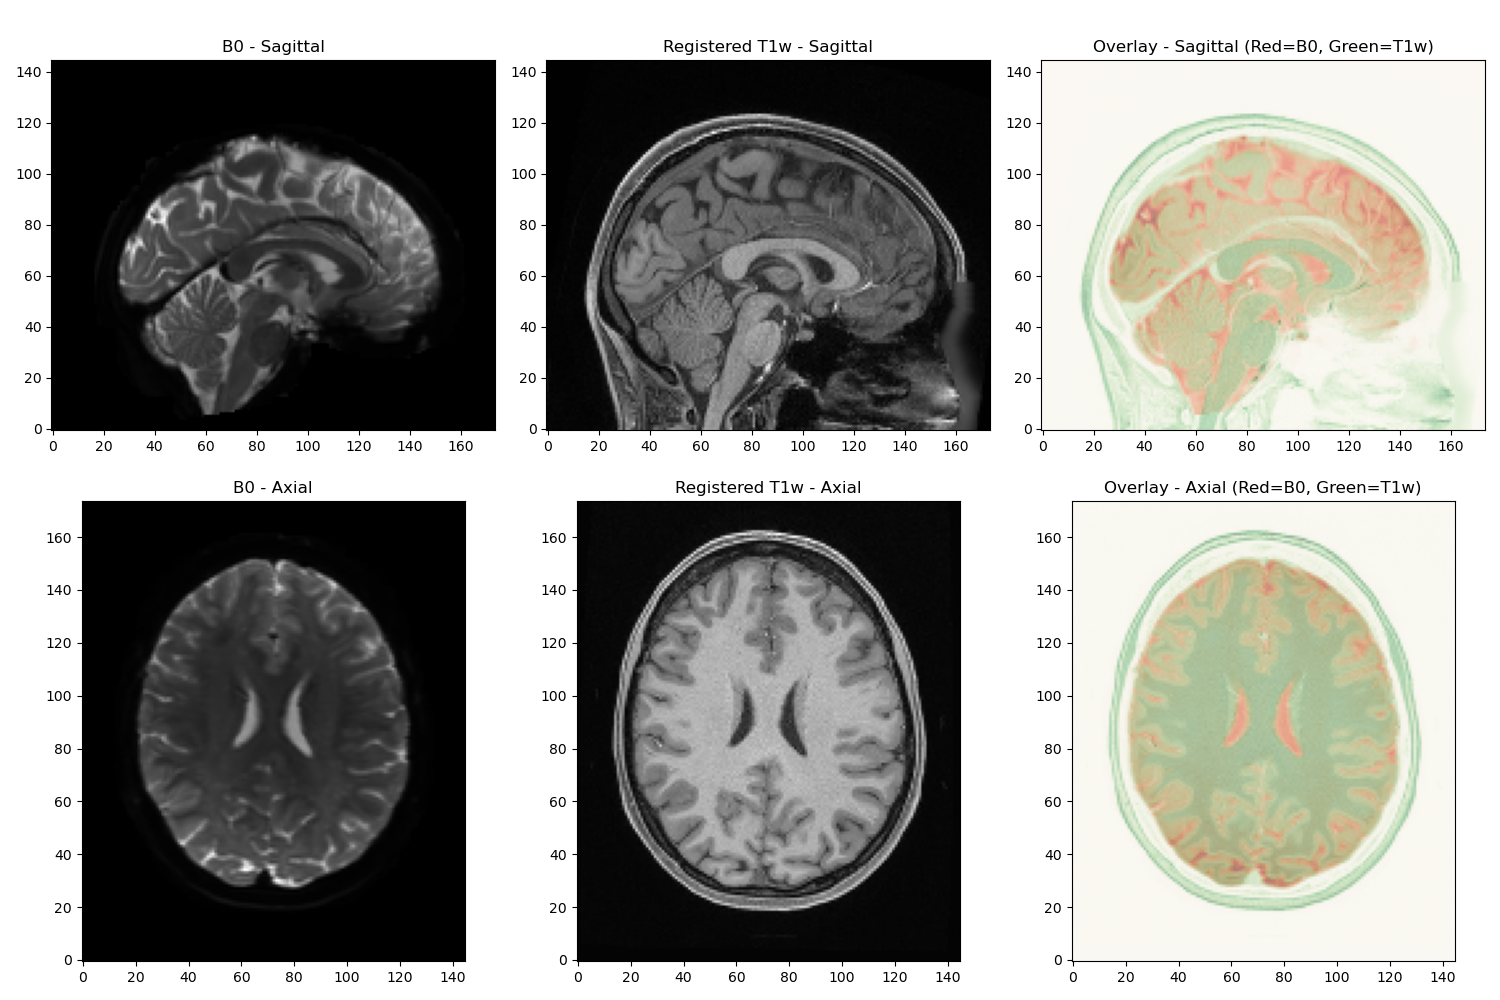

Affine transformation matrix:
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


In [53]:
skip_registration = True

# ==================== COREGISTER T1w TO DTI SPACE ====================
if skip_registration:
    print("\n*** SKIPPING REGISTRATION - Using identity transform ***")
    print("Assuming T1w and DTI are already aligned...")
    
    # Create identity affine transform
    from dipy.align.imaffine import AffineMap
    identity_matrix = np.eye(4)
    affine_registration = AffineMap(identity_matrix, 
                                    b0_image.shape, dti_affine,
                                    t1w_data.shape, t1w_affine)
    
    print("Identity transform created.")
    
else:
    print("\nCoregistering T1w to DTI space...")
    print("This may take several minutes...")

    # Set up the registration
    nbins = 32
    sampling_prop = None
    metric = MutualInformationMetric(nbins, sampling_prop)

    # Multi-stage registration: Translation -> Rigid -> Affine
    level_iters = [10000, 1000, 100]
    sigmas = [3.0, 1.0, 0.0]
    factors = [4, 2, 1]

    affreg = AffineRegistration(metric=metric,
                                level_iters=level_iters,
                                sigmas=sigmas,
                                factors=factors)

    # Stage 1: Translation
    print("  Stage 1: Translation alignment...")
    transform = TranslationTransform3D()
    params0 = None
    translation = affreg.optimize(b0_image, t1w_data, transform, params0,
                                  dti_affine, t1w_affine,
                                  starting_affine=None)

    # Stage 2: Rigid (rotation + translation)
    print("  Stage 2: Rigid alignment...")
    transform = RigidTransform3D()
    rigid = affreg.optimize(b0_image, t1w_data, transform, None,
                           dti_affine, t1w_affine,
                           starting_affine=translation.affine)

    # Stage 3: Affine (includes scaling and shearing)
    print("  Stage 3: Affine alignment...")
    transform = AffineTransform3D()
    affine_registration = affreg.optimize(b0_image, t1w_data, transform, None,
                                         dti_affine, t1w_affine,
                                         starting_affine=rigid.affine)

    print("  Registration complete!")

# Create the transformation mapping from T1w to DTI
t1w_to_dti_affine = affine_registration.affine

# ========== POST-REGISTRATION CHECK ==========
import matplotlib.pyplot as plt

# Apply the registration to transform T1w to DTI space
t1w_registered = affine_registration.transform(t1w_data)

# Create overlay visualizations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

mid_x, mid_y, mid_z = [s//2 for s in b0_image.shape]

# Sagittal slices
axes[0,0].imshow(b0_image[mid_x, :, :].T, cmap='gray', origin='lower', alpha=1.0)
axes[0,0].set_title('B0 - Sagittal')
axes[0,1].imshow(t1w_registered[mid_x, :, :].T, cmap='gray', origin='lower', alpha=1.0)
axes[0,1].set_title('Registered T1w - Sagittal')
axes[0,2].imshow(b0_image[mid_x, :, :].T, cmap='Reds', origin='lower', alpha=0.8)
axes[0,2].imshow(t1w_registered[mid_x, :, :].T, cmap='Greens', origin='lower', alpha=0.4)
axes[0,2].set_title('Overlay - Sagittal (Red=B0, Green=T1w)')

# Axial slices
axes[1,0].imshow(b0_image[:, :, mid_z].T, cmap='gray', origin='lower', alpha=1.0)
axes[1,0].set_title('B0 - Axial')
axes[1,1].imshow(t1w_registered[:, :, mid_z].T, cmap='gray', origin='lower', alpha=1.0)
axes[1,1].set_title('Registered T1w - Axial')
axes[1,2].imshow(b0_image[:, :, mid_z].T, cmap='Reds', origin='lower', alpha=0.8)
axes[1,2].imshow(t1w_registered[:, :, mid_z].T, cmap='Greens', origin='lower', alpha=0.4)
axes[1,2].set_title('Overlay - Axial (Red=B0, Green=T1w)')

plt.tight_layout()
plt.show()

print(f"Affine transformation matrix:\n{affine_registration.affine}")

In [ ]:
# ==================== CONFIG ====================
mask_subcortex = True
output_suffix = "_no_subcortex" if mask_subcortex else ""

# ==================== FIT DTI ====================
print("\nFitting DTI model...")
tensor_model = TensorModel(gtab)
tenfit = tensor_model.fit(data, mask=mask)

fa = tenfit.fa
pdd = tenfit.evecs[..., :, 0]   # principal diffusion direction


# ==================== LOAD CORTICAL SURFACE SEEDS ====================

print("\nLoading cortical surfaces...")
# Load downsampled GIFTI surfaces (white matter / grey matter boundary)
lh_surf = nib.load(f"/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/T1w/Native/{sjnr}.L.white.downsampled.surf.gii")
lh_vertices = lh_surf.darrays[0].data
lh_faces = lh_surf.darrays[1].data

rh_surf = nib.load(f"/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/T1w/Native/{sjnr}.R.white.downsampled.surf.gii")
rh_vertices = rh_surf.darrays[0].data
rh_faces = rh_surf.darrays[1].data

# Combine left and right hemisphere vertices
all_surface_vertices = np.vstack([lh_vertices, rh_vertices])
print(f"Total surface vertices: {len(all_surface_vertices)}")

# Optionally mask out subcortical vertices
if mask_subcortex:
    print("\nMasking out subcortical vertices...")
    noncortical_mask_data = np.load(f"/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/T1w/noncortical_vertex_mask.npz")
    is_noncortical_vertex = noncortical_mask_data["is_noncortical"]
    is_cortical_vertex = ~is_noncortical_vertex
    
    num_before = len(all_surface_vertices)
    all_surface_vertices = all_surface_vertices[is_cortical_vertex]
    print(f"Removed {num_before - len(all_surface_vertices)} subcortical vertices")
    print(f"Remaining cortical vertices: {len(all_surface_vertices)}")

# Transform surface vertices from T1w space to DTI space
print("Transforming surface vertices to DTI space...")
# Surface vertices are in T1w RAS space, we need them in DTI space
# Apply: T1w surface coords -> T1w voxel -> DTI voxel -> DTI RAS

# First convert surface RAS to T1w voxel coordinates
surf_voxels_t1w = nib.affines.apply_affine(np.linalg.inv(t1w_affine), all_surface_vertices)

# Then transform to DTI voxel coordinates using our registration
surf_voxels_dti = nib.affines.apply_affine(np.linalg.inv(t1w_to_dti_affine), surf_voxels_t1w)

# Finally convert to DTI RAS (mm) coordinates
all_surface_vertices_dti = nib.affines.apply_affine(dti_affine, surf_voxels_dti)


# ==================== INITIALIZE SEEDS ====================
# For each vertex, initialize 8 seeds as described in paper
n_seeds_per_vertex = 8
all_seeds_mm = []

print("Initializing seeds around each cortical vertex...")
for vertex in all_surface_vertices_dti:
    # Create 8 seeds in a small sphere around this vertex
    # Using small random offsets (e.g., within 1mm radius)
    for _ in range(n_seeds_per_vertex):
        offset = np.random.randn(3) * 2  # PREVIOUS, with white matter boudnary: 2mm std deviation
        seed = vertex + offset
        all_seeds_mm.append(seed)

seeds_mm = np.array(all_seeds_mm)
print(f"Total seeds: {len(seeds_mm)}")


# ==================== TRACTOGRAPHY WITH PAPER PARAMETERS ====================
def track_single_seed(seed_mm, max_len=2000, step=0.5, fa_threshold=0.3, max_angle=30.0):
    """
    Deterministic PDD tracker with paper parameters:
    - FA threshold: 0.3 (termination criteria)
    - Minimum tract length: 20mm (checked after tracking)
    - Maximum angle between steps: 30 degrees
    
    Returns list of points in mm, or None if tract too short.
    """
    def mm_to_ijk(pt):
        return np.round(nib.affines.apply_affine(inv_dti_affine, pt)).astype(int)

    streamline = [seed_mm.copy()]
    prev_dir = None

    for direction_sign in [+1, -1]:
        pos = seed_mm.copy()
        local_prev_dir = prev_dir

        for _ in range(max_len):
            ijk = mm_to_ijk(pos)

            # Stop if outside volume
            if np.any(ijk < 0) or ijk[0] >= fa.shape[0] or ijk[1] >= fa.shape[1] or ijk[2] >= fa.shape[2]:
                break

            # Stop if FA below threshold (paper: FA < 0.3)
            if fa[tuple(ijk)] < fa_threshold:
                break

            # Local direction
            v = pdd[tuple(ijk)]
            if np.linalg.norm(v) == 0:
                break

            v = v / np.linalg.norm(v)
            v *= direction_sign

            # Check angle with previous direction (paper: max 30 degrees)
            if local_prev_dir is not None:
                angle = np.arccos(np.clip(np.abs(np.dot(v, local_prev_dir)), 0, 1))
                angle_deg = np.degrees(angle)
                if angle_deg > max_angle:
                    break

            # Advance
            pos = pos + step * v
            
            if direction_sign == 1:
                streamline.append(pos.copy())
            else:
                streamline.insert(0, pos.copy())
            
            local_prev_dir = v

        # Save direction for next iteration
        if direction_sign == 1 and len(streamline) > 1:
            prev_dir = -v  # flip for opposite direction

    # Calculate tract length
    if len(streamline) < 2:
        return None
    
    streamline_arr = np.array(streamline)
    tract_length = np.sum(np.linalg.norm(np.diff(streamline_arr, axis=0), axis=1))
    
    # Paper: minimum tract length 20 mm
    if tract_length < 20.0:
        return None
    
    return streamline


# ==================== RUN TRACKING ====================
print("\nRunning tractography...")
all_streamlines = []
for i, s in enumerate(seeds_mm):
    if i % 10000 == 0:
        print(f"  Processing seed {i}/{len(seeds_mm)}...")
    
    sl = track_single_seed(s, fa_threshold=0.3, max_len=500, max_angle=30.0)
    if sl is not None:
        all_streamlines.append(sl)

print(f"\nGenerated {len(all_streamlines)} streamlines (after filtering).")

# ==================== SAVE ====================
np.savez(f"/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/fiber_paths_surface_seeded{output_suffix}.npz", fiber_paths=np.array(all_streamlines, dtype=object))
print(f"Saved fiber_paths_surface_seeded{output_suffix}.npz")

# Also save the registration transform for future reference
np.save(f"/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/t1w_to_dti_affine.npy", t1w_to_dti_affine)
print("Saved registration transform to t1w_to_dti_affine.npy")

# Summary statistics
lengths = [np.sum(np.linalg.norm(np.diff(np.array(sl), axis=0), axis=1)) for sl in all_streamlines]
print(f"\nTract length statistics:")
print(f"  Mean: {np.mean(lengths):.2f} mm")
print(f"  Median: {np.median(lengths):.2f} mm")
print(f"  Min: {np.min(lengths):.2f} mm")
print(f"  Max: {np.max(lengths):.2f} mm")


Fitting DTI model...

Loading cortical surfaces...
Total surface vertices: 20741

Masking out subcortical vertices...
Removed 764 subcortical vertices
Remaining cortical vertices: 19977
Transforming surface vertices to DTI space...
Initializing seeds around each cortical vertex...
Total seeds: 159816

Running tractography...
  Processing seed 0/159816...
  Processing seed 10000/159816...
  Processing seed 20000/159816...
  Processing seed 30000/159816...
  Processing seed 40000/159816...
  Processing seed 50000/159816...
  Processing seed 60000/159816...
  Processing seed 70000/159816...
  Processing seed 80000/159816...
  Processing seed 90000/159816...
  Processing seed 100000/159816...
  Processing seed 110000/159816...
  Processing seed 120000/159816...
  Processing seed 130000/159816...
  Processing seed 140000/159816...
  Processing seed 150000/159816...

Generated 12198 streamlines (after filtering).
Saved fiber_paths_surface_seeded_no_subcortex.npz
Saved registration transform

Loading surfaces...
Loaded 20741 surface vertices
Loading streamlines...
Loaded 12198 streamlines
Creating visualization...

Saved visualization to 'tractography_visualization_no_subcortex.png'

=== STATISTICS ===
Surface vertices in DTI space:
  X range: [-65.3, 65.6] mm
  Y range: [-95.3, 64.5] mm
  Z range: [-45.5, 67.9] mm

Streamlines in DTI space:
  X range: [-61.9, 61.4] mm
  Y range: [-92.0, 61.3] mm
  Z range: [-38.3, 66.3] mm


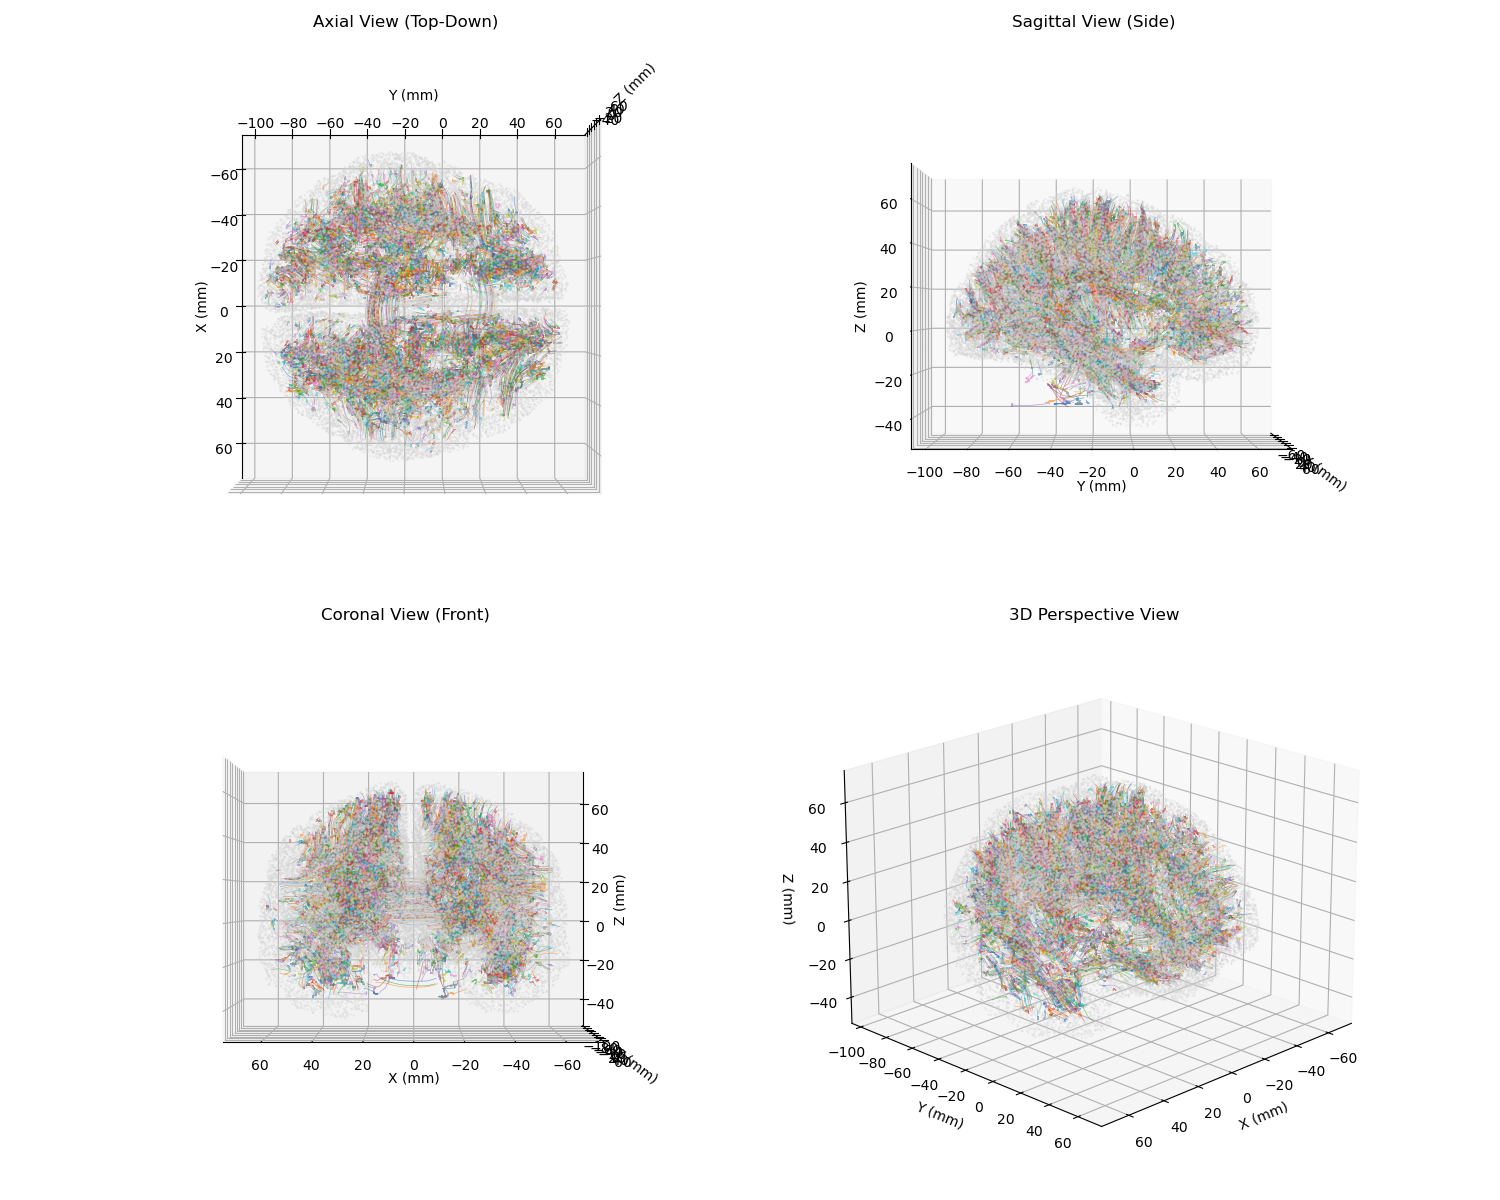

In [55]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ==================== LOAD SURFACES ====================
print("Loading surfaces...")
lh_surf = nib.load(f"/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/T1w/Native/{sjnr}.L.midthickness.downsampled.surf.gii")
lh_vertices = lh_surf.darrays[0].data

rh_surf = nib.load(f"/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/T1w/Native/{sjnr}.R.midthickness.downsampled.surf.gii")
rh_vertices = rh_surf.darrays[0].data

# Combine surfaces
all_vertices = np.vstack([lh_vertices, rh_vertices])
print(f"Loaded {len(all_vertices)} surface vertices")

# Transform to DTI space using saved registration
t1w_to_dti_affine = np.load(f"/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/t1w_to_dti_affine.npy")

try:
    t1w_img = nib.load(f"/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/T1w/T1w_acpc_dc_restore_1.05.nii.gz")
except:
    t1w_img = nib.load(f"/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/T1w/T1w_acpc_dc_restore_1.25.nii.gz")

t1w_affine = t1w_img.affine
dti_img = nib.load(f"{diffusion_path}/data.nii.gz")
dti_affine = dti_img.affine

# Transform vertices to DTI space
surf_voxels_t1w = nib.affines.apply_affine(np.linalg.inv(t1w_affine), all_vertices)
surf_voxels_dti = nib.affines.apply_affine(np.linalg.inv(t1w_to_dti_affine), surf_voxels_t1w)
vertices_dti = nib.affines.apply_affine(dti_affine, surf_voxels_dti)

# ==================== LOAD STREAMLINES ====================
print("Loading streamlines...")
data = np.load(f"/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/fiber_paths_surface_seeded{output_suffix}.npz", allow_pickle=True)
streamlines = data['fiber_paths']
print(f"Loaded {len(streamlines)} streamlines")

# Subsample streamlines for visualization (too many to plot)
n_streamlines_to_plot = min(8000, len(streamlines))
indices = np.random.choice(len(streamlines), n_streamlines_to_plot, replace=False)
streamlines_subset = [streamlines[i] for i in indices]

# ==================== CREATE VISUALIZATION ====================
print("Creating visualization...")
fig = plt.figure(figsize=(15, 12))

# View 1: Axial (top-down)
ax1 = fig.add_subplot(221, projection='3d')
ax1.scatter(vertices_dti[:, 0], vertices_dti[:, 1], vertices_dti[:, 2], 
           c='lightgray', s=0.5, alpha=0.3, label='Cortical surface')
for sl in streamlines_subset:
    sl_arr = np.array(sl)
    ax1.plot(sl_arr[:, 0], sl_arr[:, 1], sl_arr[:, 2], 
            linewidth=0.5, alpha=0.6)
ax1.set_xlabel('X (mm)')
ax1.set_ylabel('Y (mm)')
ax1.set_zlabel('Z (mm)')
ax1.set_title('Axial View (Top-Down)')
ax1.view_init(elev=90, azim=0)

# View 2: Sagittal (side view)
ax2 = fig.add_subplot(222, projection='3d')
ax2.scatter(vertices_dti[:, 0], vertices_dti[:, 1], vertices_dti[:, 2], 
           c='lightgray', s=0.5, alpha=0.3)
for sl in streamlines_subset:
    sl_arr = np.array(sl)
    ax2.plot(sl_arr[:, 0], sl_arr[:, 1], sl_arr[:, 2], 
            linewidth=0.5, alpha=0.6)
ax2.set_xlabel('X (mm)')
ax2.set_ylabel('Y (mm)')
ax2.set_zlabel('Z (mm)')
ax2.set_title('Sagittal View (Side)')
ax2.view_init(elev=0, azim=0)

# View 3: Coronal (front view)
ax3 = fig.add_subplot(223, projection='3d')
ax3.scatter(vertices_dti[:, 0], vertices_dti[:, 1], vertices_dti[:, 2], 
           c='lightgray', s=0.5, alpha=0.3)
for sl in streamlines_subset:
    sl_arr = np.array(sl)
    ax3.plot(sl_arr[:, 0], sl_arr[:, 1], sl_arr[:, 2], 
            linewidth=0.5, alpha=0.6)
ax3.set_xlabel('X (mm)')
ax3.set_ylabel('Y (mm)')
ax3.set_zlabel('Z (mm)')
ax3.set_title('Coronal View (Front)')
ax3.view_init(elev=0, azim=90)

# View 4: 3D perspective
ax4 = fig.add_subplot(224, projection='3d')
ax4.scatter(vertices_dti[:, 0], vertices_dti[:, 1], vertices_dti[:, 2], 
           c='lightgray', s=0.5, alpha=0.3)
for sl in streamlines_subset:
    sl_arr = np.array(sl)
    ax4.plot(sl_arr[:, 0], sl_arr[:, 1], sl_arr[:, 2], 
            linewidth=0.5, alpha=0.6)
ax4.set_xlabel('X (mm)')
ax4.set_ylabel('Y (mm)')
ax4.set_zlabel('Z (mm)')
ax4.set_title('3D Perspective View')
ax4.view_init(elev=20, azim=45)

plt.tight_layout()
plt.savefig(f"/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/tractography_visualization{output_suffix}.png", dpi=150, bbox_inches='tight')
print(f"\nSaved visualization to 'tractography_visualization{output_suffix}.png'")

# ==================== PRINT STATISTICS ====================
print("\n=== STATISTICS ===")
print(f"Surface vertices in DTI space:")
print(f"  X range: [{vertices_dti[:, 0].min():.1f}, {vertices_dti[:, 0].max():.1f}] mm")
print(f"  Y range: [{vertices_dti[:, 1].min():.1f}, {vertices_dti[:, 1].max():.1f}] mm")
print(f"  Z range: [{vertices_dti[:, 2].min():.1f}, {vertices_dti[:, 2].max():.1f}] mm")

# Get streamline bounds
all_points = []
for sl in streamlines:
    all_points.extend(sl)
all_points = np.array(all_points)

print(f"\nStreamlines in DTI space:")
print(f"  X range: [{all_points[:, 0].min():.1f}, {all_points[:, 0].max():.1f}] mm")
print(f"  Y range: [{all_points[:, 1].min():.1f}, {all_points[:, 1].max():.1f}] mm")
print(f"  Z range: [{all_points[:, 2].min():.1f}, {all_points[:, 2].max():.1f}] mm")

plt.show()

Loading surfaces...
Total vertices (before masking): 20741
Total faces (before masking): 41474

Masking out subcortical vertices...
Total vertices (after masking): 19977
Total faces (after masking): 39831
Transforming surface vertices to DTI space...
Vertex coordinates in DTI space (meters):
  X range: [-0.0653, 0.0656] m
  Y range: [-0.0953, 0.0645] m
  Z range: [-0.0455, 0.0679] m

Building MRI adjacency matrix from mesh...
Found 59806 unique MRI edges from mesh
Added 59806 MRI edges to adjacency matrix

Building MRI-only adjacency matrix...
MRI-only degree statistics:
  Min: 185348.289833
  Max: 8650061.144230
  Mean: 810179.596864

Loading streamlines...
Loaded 12198 streamlines
Building KD-tree for vertex lookup...

Adding DTI edges (threshold: 20.0 mm, speed factor: 50.0)...
Added 11277 DTI edges
Skipped 921 DTI edges (threshold or same vertex)

Building DTI-only adjacency matrix...
DTI-only degree statistics:
  Min: 0.000000
  Max: 175253073.587145
  Mean: 1664431.530772
  Verti

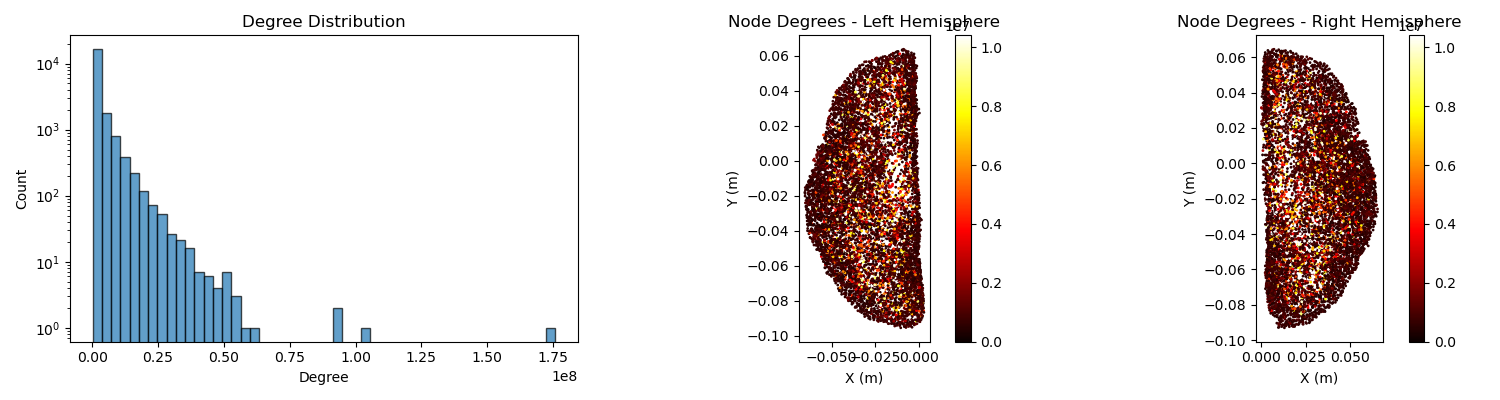

In [56]:
import numpy as np
import nibabel as nib
from scipy.spatial import cKDTree
from scipy.sparse import csr_matrix, diags
import matplotlib.pyplot as plt

# User parameters
distance_threshold_mm = 20.0  # Maximum distance from fiber endpoint to nearest vertex (in mm normally 5)
speed_factor = 50.0  # Speed factor for DTI edge weights

output_suffix = "_no_subcortex" if mask_subcortex else ""

# ==================== LOAD SURFACES ====================
print("Loading surfaces...")
lh_surf = nib.load(f"/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/T1w/Native/{sjnr}.L.midthickness.downsampled.surf.gii")
lh_vertices = lh_surf.darrays[0].data
lh_faces = lh_surf.darrays[1].data

rh_surf = nib.load(f"/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/T1w/Native/{sjnr}.R.midthickness.downsampled.surf.gii")
rh_vertices = rh_surf.darrays[0].data
rh_faces = rh_surf.darrays[1].data

# Combine surfaces
n_lh = len(lh_vertices)
n_rh = len(rh_vertices)
all_vertices = np.vstack([lh_vertices, rh_vertices])
# Adjust right hemisphere face indices
rh_faces_adjusted = rh_faces + n_lh
all_faces = np.vstack([lh_faces, rh_faces_adjusted])

print(f"Total vertices (before masking): {len(all_vertices)}")
print(f"Total faces (before masking): {len(all_faces)}")

# Optionally remove subcortical vertices and remap faces
if mask_subcortex:
    print("\nMasking out subcortical vertices...")
    noncortical_mask_data = np.load(f"/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/T1w/noncortical_vertex_mask.npz")
    is_cortical_vertex = ~noncortical_mask_data["is_noncortical"]
    
    # Build remapping from old vertex indices to new compact indices
    old_to_new_vertex_index = np.full(len(all_vertices), -1, dtype=np.int64)
    old_to_new_vertex_index[is_cortical_vertex] = np.arange(np.sum(is_cortical_vertex))
    
    # Keep only faces where all three vertices are cortical
    cortical_faces_mask = (
        is_cortical_vertex[all_faces[:, 0]] &
        is_cortical_vertex[all_faces[:, 1]] &
        is_cortical_vertex[all_faces[:, 2]]
    )
    all_faces = old_to_new_vertex_index[all_faces[cortical_faces_mask]]
    all_vertices = all_vertices[is_cortical_vertex]
    
    # Update hemisphere vertex counts
    original_n_lh = n_lh
    n_lh = np.sum(is_cortical_vertex[:original_n_lh])
    n_rh = np.sum(is_cortical_vertex[original_n_lh:])
    
    print(f"Total vertices (after masking): {len(all_vertices)}")
    print(f"Total faces (after masking): {len(all_faces)}")

# Transform to DTI space using saved registration
print("Transforming surface vertices to DTI space...")
t1w_to_dti_affine = np.load(f"/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/t1w_to_dti_affine.npy")

try:
    t1w_img = nib.load(f"/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/T1w/T1w_acpc_dc_restore_1.05.nii.gz")
except:
    t1w_img = nib.load(f"/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/T1w/T1w_acpc_dc_restore_1.25.nii.gz")


t1w_affine = t1w_img.affine
dti_img = nib.load(f"{diffusion_path}/data.nii.gz")
dti_affine = dti_img.affine

# Transform vertices to DTI space (mm)
surf_voxels_t1w = nib.affines.apply_affine(np.linalg.inv(t1w_affine), all_vertices)
surf_voxels_dti = nib.affines.apply_affine(np.linalg.inv(t1w_to_dti_affine), surf_voxels_t1w)
vertices_dti_mm = nib.affines.apply_affine(dti_affine, surf_voxels_dti)

# Convert to meters
vertices_dti_m = vertices_dti_mm / 1000.0

print(f"Vertex coordinates in DTI space (meters):")
print(f"  X range: [{vertices_dti_m[:, 0].min():.4f}, {vertices_dti_m[:, 0].max():.4f}] m")
print(f"  Y range: [{vertices_dti_m[:, 1].min():.4f}, {vertices_dti_m[:, 1].max():.4f}] m")
print(f"  Z range: [{vertices_dti_m[:, 2].min():.4f}, {vertices_dti_m[:, 2].max():.4f}] m")

# ==================== BUILD MRI ADJACENCY FROM MESH ====================
print("\nBuilding MRI adjacency matrix from mesh...")
n_vertices = len(vertices_dti_m)

# Extract edges from triangular faces
edges = []
for face in all_faces:
    # Each triangle has 3 edges
    edges.append((face[0], face[1]))
    edges.append((face[1], face[2]))
    edges.append((face[2], face[0]))

# Remove duplicates and self-loops
edges = set(edges)
edges = [(min(i, j), max(i, j)) for i, j in edges if i != j]
edges = list(set(edges))

print(f"Found {len(edges)} unique MRI edges from mesh")

# Build sparse adjacency matrix with MRI edges
# Weight = 1 / d^2 where d is Euclidean distance in meters
row_indices_mri = []
col_indices_mri = []
weights_mri = []

for i, j in edges:
    dist = np.linalg.norm(vertices_dti_m[i] - vertices_dti_m[j])
    if dist > 0:
        weight = 1.0 / (dist ** 2)
        # Symmetric matrix
        row_indices_mri.extend([i, j])
        col_indices_mri.extend([j, i])
        weights_mri.extend([weight, weight])

print(f"Added {len(edges)} MRI edges to adjacency matrix")

# ==================== BUILD MRI-ONLY ADJACENCY AND COMPUTE DEGREES ====================
print("\nBuilding MRI-only adjacency matrix...")
A_mri = csr_matrix((weights_mri, (row_indices_mri, col_indices_mri)), shape=(n_vertices, n_vertices))
A_mri.sum_duplicates()
degrees_mri = np.array(A_mri.sum(axis=1)).flatten()
print(f"MRI-only degree statistics:")
print(f"  Min: {degrees_mri.min():.6f}")
print(f"  Max: {degrees_mri.max():.6f}")
print(f"  Mean: {degrees_mri.mean():.6f}")

# ==================== LOAD STREAMLINES ====================
print("\nLoading streamlines...")
data = np.load(f"/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/fiber_paths_surface_seeded{output_suffix}.npz", allow_pickle=True)
streamlines = data['fiber_paths']
print(f"Loaded {len(streamlines)} streamlines")

# Convert streamlines from mm to meters
streamlines_m = []
for sl in streamlines:
    streamlines_m.append(np.array(sl) / 1000.0)

# ==================== BUILD KD-TREE FOR NEAREST NEIGHBOR SEARCH ====================
print("Building KD-tree for vertex lookup...")
kdtree = cKDTree(vertices_dti_m)
distance_threshold_m = distance_threshold_mm / 1000.0

# ==================== ADD DTI EDGES ====================
print(f"\nAdding DTI edges (threshold: {distance_threshold_mm} mm, speed factor: {speed_factor})...")
dti_edges_added = 0
dti_edges_skipped = 0

row_indices_dti = []
col_indices_dti = []
weights_dti = []

for sl in streamlines_m:
    if len(sl) < 2:
        continue
    
    start_point = sl[0]
    end_point = sl[-1]
    
    # Find nearest vertices to start and end
    dist_start, idx_start = kdtree.query(start_point)
    dist_end, idx_end = kdtree.query(end_point)
    
    # Check distance threshold
    if dist_start > distance_threshold_m or dist_end > distance_threshold_m:
        dti_edges_skipped += 1
        continue
    
    # Check if same vertex
    if idx_start == idx_end:
        dti_edges_skipped += 1
        continue
    
    # Calculate path length along streamline
    path_length = np.sum(np.linalg.norm(np.diff(sl, axis=0), axis=1))
    
    # DTI edge weight: 1 / (path_length / speed_factor)^2
    effective_distance = path_length / speed_factor
    if effective_distance > 0:
        weight = 1.0 / (effective_distance ** 2)
        
        # Add symmetric edge
        row_indices_dti.extend([idx_start, idx_end])
        col_indices_dti.extend([idx_end, idx_start])
        weights_dti.extend([weight, weight])
        dti_edges_added += 1

print(f"Added {dti_edges_added} DTI edges")
print(f"Skipped {dti_edges_skipped} DTI edges (threshold or same vertex)")

# ==================== BUILD DTI-ONLY ADJACENCY AND COMPUTE DEGREES ====================
print("\nBuilding DTI-only adjacency matrix...")
A_dti = csr_matrix((weights_dti, (row_indices_dti, col_indices_dti)), shape=(n_vertices, n_vertices))
A_dti.sum_duplicates()
degrees_dti = np.array(A_dti.sum(axis=1)).flatten()
print(f"DTI-only degree statistics:")
print(f"  Min: {degrees_dti.min():.6f}")
print(f"  Max: {degrees_dti.max():.6f}")
print(f"  Mean: {degrees_dti.mean():.6f}")
print(f"  Vertices with DTI connections: {np.sum(degrees_dti > 0)}")

# ==================== BUILD COMBINED ADJACENCY MATRIX ====================
print("\nBuilding combined adjacency matrix...")
row_indices = row_indices_mri + row_indices_dti
col_indices = col_indices_mri + col_indices_dti
weights = weights_mri + weights_dti

A = csr_matrix((weights, (row_indices, col_indices)), shape=(n_vertices, n_vertices))

# Sum duplicate edges (if any fiber connects same vertices)
A.sum_duplicates()

print(f"Adjacency matrix shape: {A.shape}")
print(f"Number of non-zero entries: {A.nnz}")
print(f"Sparsity: {100 * (1 - A.nnz / (n_vertices ** 2)):.2f}%")

# ==================== BUILD DEGREE MATRIX ====================
print("Building degree matrix...")
# Degree is sum of weights for each node
degrees = np.array(A.sum(axis=1)).flatten()
D = diags(degrees, format='csr')

print(f"Combined degree statistics:")
print(f"  Min: {degrees.min():.6f}")
print(f"  Max: {degrees.max():.6f}")
print(f"  Mean: {degrees.mean():.6f}")
print(f"  Median: {np.median(degrees):.6f}")

# ==================== COMPUTE GRAPH LAPLACIAN ====================
print("\nComputing graph Laplacian (L = A - D)...")
L = A - D

print(f"Laplacian matrix shape: {L.shape}")
print(f"Laplacian is symmetric: {np.allclose(L.data, L.T.data)}")

# ==================== SAVE RESULTS ====================
print("\nSaving results...")
from scipy.sparse import save_npz
save_npz(f"/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/graph_laplacian{output_suffix}.npz", L)
save_npz(f"/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/adjacency_matrix{output_suffix}.npz", A)
save_npz(f"/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/degree_matrix{output_suffix}.npz", D)
np.save(f"/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/vertex_degrees{output_suffix}.npy", degrees)
np.save(f"/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/vertex_degrees_mri_only{output_suffix}.npy", degrees_mri)
np.save(f"/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/vertex_degrees_dti_only{output_suffix}.npy", degrees_dti)

print("Saved:")
print(f"  - graph_laplacian{output_suffix}.npz")
print(f"  - adjacency_matrix{output_suffix}.npz")
print(f"  - degree_matrix{output_suffix}.npz")
print(f"  - vertex_degrees{output_suffix}.npy (combined MRI + DTI)")
print(f"  - vertex_degrees_mri_only{output_suffix}.npy")
print(f"  - vertex_degrees_dti_only{output_suffix}.npy")

# ==================== VISUALIZATION ====================
print("\nCreating degree distribution visualization...")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram of degrees
axes[0].hist(degrees, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Degree')
axes[0].set_ylabel('Count')
axes[0].set_title('Degree Distribution')
axes[0].set_yscale('log')

# Degree map on surface (left hemisphere)
scatter1 = axes[1].scatter(vertices_dti_m[:n_lh, 0], vertices_dti_m[:n_lh, 1], 
                           c=degrees[:n_lh], s=1, cmap='hot', vmin=0, vmax=np.percentile(degrees, 95))
axes[1].set_xlabel('X (m)')
axes[1].set_ylabel('Y (m)')
axes[1].set_title('Node Degrees - Left Hemisphere')
axes[1].set_aspect('equal')
plt.colorbar(scatter1, ax=axes[1])

# Degree map on surface (right hemisphere)
scatter2 = axes[2].scatter(vertices_dti_m[n_lh:, 0], vertices_dti_m[n_lh:, 1], 
                           c=degrees[n_lh:], s=1, cmap='hot', vmin=0, vmax=np.percentile(degrees, 95))
axes[2].set_xlabel('X (m)')
axes[2].set_ylabel('Y (m)')
axes[2].set_title('Node Degrees - Right Hemisphere')
axes[2].set_aspect('equal')
plt.colorbar(scatter2, ax=axes[2])

plt.tight_layout()
plt.savefig(f"/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/degree_distribution{output_suffix}.png", dpi=150, bbox_inches='tight')
print(f"Saved degree_distribution{output_suffix}.png")

# ==================== SUMMARY ====================
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"Total vertices: {n_vertices}")
print(f"MRI edges: {len(edges)}")
print(f"DTI edges: {dti_edges_added}")
print(f"Total edges: {len(edges) + dti_edges_added}")
print(f"Adjacency matrix non-zeros: {A.nnz}")
print(f"Distance threshold: {distance_threshold_mm} mm")
print(f"Speed factor: {speed_factor}")
print("="*60)

plt.show()

In [57]:
from scipy.sparse import load_npz
import numpy as np

# Load sparse Laplacian
L = load_npz(f"/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/graph_laplacian{output_suffix}.npz")

# Convert to dense for full eigendecomposition
L_dense = L.toarray()

s,U=np.linalg.eigh(L_dense)

np.save(f"/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/eigenvalues{output_suffix}.npy", s[::-1])

np.save(f"/Users/marcoaqil/Desktop/miami_mac/Downloads/{sjnr}/eigenvectors{output_suffix}.npy", U[:,::-1])

Creating mesh...
Total points: 230

Building mesh-based graph...
Target degree: 891.5

Building LP-balanced graph...
  Candidate edges: 3789
  Solving LP...
  LP failed: The problem is infeasible. (HiGHS Status 8: model_status is Infeasible; primal_status is None)
  Trying with inequality constraints (<= target) instead...
  Optimization successful
  Probability range: [0.000, 1.000]
  Mean probability: 0.353
  Expected degree range: [494.8, 891.5]

Visualizing...


/var/folders/q7/_144hn9j53d8r1w3x2_qn3r80000gq/T/ipykernel_59029/3746192233.py:253: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True)


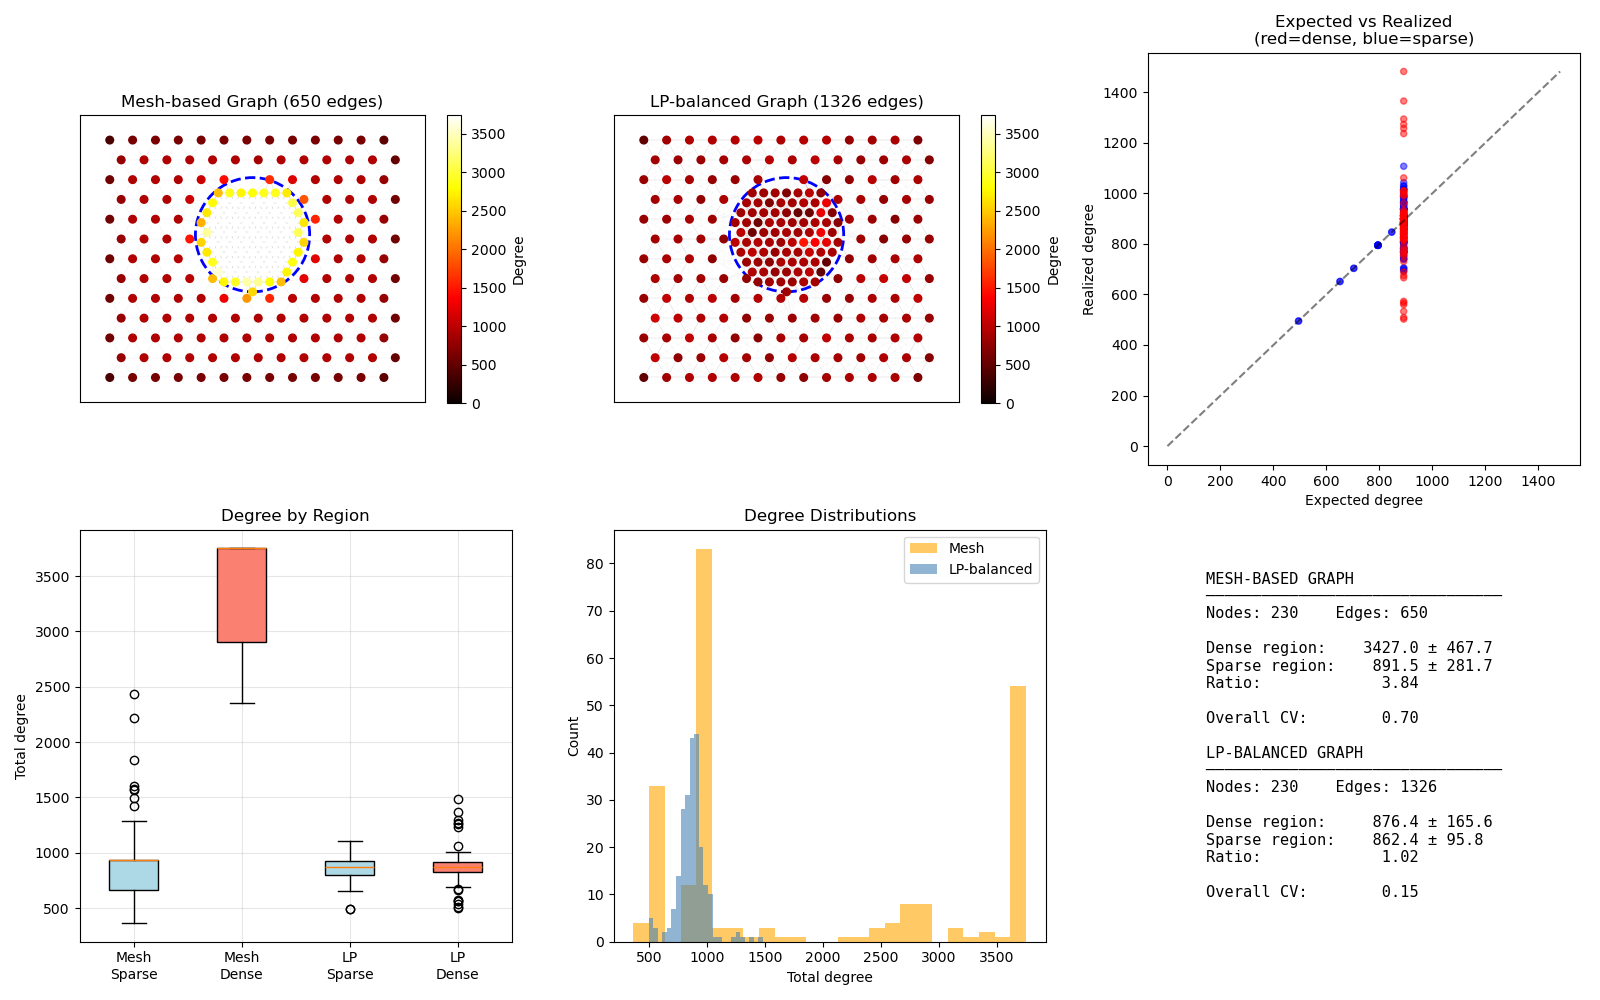

({0: np.float64(364.5833333333333),
  1: np.float64(625.0),
  2: np.float64(625.0),
  3: np.float64(625.0),
  4: np.float64(624.9999999999999),
  5: np.float64(624.9999999999999),
  6: np.float64(625.0),
  7: np.float64(625.0000000000002),
  8: np.float64(625.0000000000005),
  9: np.float64(625.0000000000005),
  10: np.float64(625.0000000000005),
  11: np.float64(625.0000000000005),
  12: np.float64(468.7500000000003),
  13: np.float64(781.25),
  14: np.float64(937.5),
  15: np.float64(937.5),
  16: np.float64(937.4999999999998),
  17: np.float64(937.5),
  18: np.float64(937.5000000000002),
  19: np.float64(937.5000000000005),
  20: np.float64(937.5000000000007),
  21: np.float64(937.5000000000007),
  22: np.float64(937.5000000000007),
  23: np.float64(937.5000000000007),
  24: np.float64(937.5000000000007),
  25: np.float64(520.8333333333338),
  26: np.float64(572.9166666666667),
  27: np.float64(937.5000000000002),
  28: np.float64(937.5000000000002),
  29: np.float64(937.50000000000

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
from scipy.spatial.distance import cdist
from scipy.optimize import minimize
import networkx as nx

# =============================================================================
# Mesh creation and standard graph (same as before)
# =============================================================================

def create_triangular_mesh_with_dense_region(
    dense_center=(0.5, 0.5),
    dense_radius=0.2,
    base_spacing=0.1,
    dense_spacing=0.05
):
    points = []
    
    rows = int(1.0 / base_spacing) + 1
    for i in range(rows):
        y = i * base_spacing * np.sqrt(3) / 2
        if y > 1.0:
            break
        offset = (i % 2) * base_spacing / 2
        x = offset
        while x <= 1.0:
            dist_to_center = np.sqrt((x - dense_center[0])**2 + (y - dense_center[1])**2)
            if dist_to_center > dense_radius:
                points.append([x, y])
            x += base_spacing
    
    dense_rows = int(2 * dense_radius / dense_spacing) + 1
    for i in range(dense_rows):
        y = dense_center[1] - dense_radius + i * dense_spacing * np.sqrt(3) / 2
        if y < 0 or y > 1.0:
            continue
        offset = (i % 2) * dense_spacing / 2
        x_start = dense_center[0] - dense_radius
        x = x_start + offset
        while x <= dense_center[0] + dense_radius:
            dist_to_center = np.sqrt((x - dense_center[0])**2 + (y - dense_center[1])**2)
            if dist_to_center <= dense_radius and 0 <= x <= 1.0:
                points.append([x, y])
            x += dense_spacing
    
    return np.array(points)

def build_mesh_graph(points):
    tri = Delaunay(points)
    G = nx.Graph()
    
    for i in range(len(points)):
        G.add_node(i, pos=points[i])
    
    edges_set = set()
    for simplex in tri.simplices:
        for i in range(3):
            for j in range(i+1, 3):
                edge = tuple(sorted([simplex[i], simplex[j]]))
                edges_set.add(edge)
    
    for (i, j) in edges_set:
        dist = np.linalg.norm(points[i] - points[j])
        weight = 1.0 / (dist ** 2)
        G.add_edge(i, j, weight=weight)
    
    return G

def compute_node_degrees(G):
    degrees = {}
    for node in G.nodes():
        degree = sum(G[node][neighbor]['weight'] for neighbor in G.neighbors(node))
        degrees[node] = degree
    return degrees

# =============================================================================
# PRINCIPLED APPROACH: Constrained optimization
# =============================================================================

def build_balanced_graph_optimization(points, target_degree, distance_threshold=0.25, seed=42):
    """
    Find edge probabilities by solving a convex optimization problem.
    
    Objective: Maximize sum of p_ij * w_ij (prefer high-weight edges)
               or equivalently, minimize total "distance cost" of the graph
    
    Constraints: 
        - sum_j(p_ij * w_ij) = target_degree for all i
        - 0 <= p_ij <= 1
    
    This is a linear program!
    """
    from scipy.optimize import linprog
    
    np.random.seed(seed)
    N = len(points)
    distances = cdist(points, points)
    
    # Build list of candidate edges (within threshold)
    candidate_edges = []
    for i in range(N):
        for j in range(i+1, N):
            if distances[i, j] < distance_threshold:
                w = 1.0 / (distances[i, j] ** 2)
                candidate_edges.append((i, j, w))
    
    M = len(candidate_edges)
    print(f"  Candidate edges: {M}")
    
    if M == 0:
        print("  No candidate edges!")
        G = nx.Graph()
        for i in range(N):
            G.add_node(i, pos=points[i])
        return G, np.array([])
    
    # Decision variables: p_e for each edge e
    # Objective: maximize sum(p_e * w_e) => minimize sum(-p_e * w_e)
    c = np.array([-e[2] for e in candidate_edges])  # negative for maximization
    
    # Equality constraints: for each node i, sum of (p_e * w_e) for edges containing i = target
    A_eq = np.zeros((N, M))
    for e_idx, (i, j, w) in enumerate(candidate_edges):
        A_eq[i, e_idx] = w
        A_eq[j, e_idx] = w
    b_eq = np.full(N, target_degree)
    
    # Bounds: 0 <= p_e <= 1
    bounds = [(0, 1) for _ in range(M)]
    
    print("  Solving LP...")
    result = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')
    
    if not result.success:
        print(f"  LP failed: {result.message}")
        print("  Trying with inequality constraints (<= target) instead...")
        # Try inequality: allow degrees UP TO target
        A_ub = A_eq
        b_ub = b_eq
        result = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')
        
        if not result.success:
            print(f"  Still failed: {result.message}")
            # Return empty graph
            G = nx.Graph()
            for i in range(N):
                G.add_node(i, pos=points[i])
            return G, np.array([])
    
    p_opt = result.x
    print(f"  Optimization successful")
    print(f"  Probability range: [{p_opt.min():.3f}, {p_opt.max():.3f}]")
    print(f"  Mean probability: {p_opt.mean():.3f}")
    
    # Compute expected degrees
    expected_degrees = A_eq @ p_opt
    print(f"  Expected degree range: [{expected_degrees.min():.1f}, {expected_degrees.max():.1f}]")
    
    # Sample edges
    G = nx.Graph()
    for i in range(N):
        G.add_node(i, pos=points[i])
    
    random_vals = np.random.random(M)
    for e_idx, (i, j, w) in enumerate(candidate_edges):
        if random_vals[e_idx] < p_opt[e_idx]:
            G.add_edge(i, j, weight=w)
    
    return G, p_opt, expected_degrees, candidate_edges

# =============================================================================
# Visualization
# =============================================================================

def visualize_comparison(points, G_mesh, G_prob, dense_center, dense_radius, 
                         expected_degrees=None):
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    
    pos = {i: points[i] for i in range(len(points))}
    
    degrees_mesh = compute_node_degrees(G_mesh)
    degrees_prob = compute_node_degrees(G_prob)
    
    in_dense = []
    for i, p in enumerate(points):
        dist = np.sqrt((p[0] - dense_center[0])**2 + (p[1] - dense_center[1])**2)
        in_dense.append(dist <= dense_radius)
    
    all_degrees = list(degrees_mesh.values()) + list(degrees_prob.values())
    if len(all_degrees) > 0 and max(all_degrees) > 0:
        vmin, vmax = 0, max(all_degrees)
    else:
        vmin, vmax = 0, 1
    
    # Mesh-based graph
    ax = axes[0, 0]
    if G_mesh.edges():
        edge_weights = [G_mesh[u][v]['weight'] for u, v in G_mesh.edges()]
        max_weight = max(edge_weights)
        edge_widths = [0.5 * w / max_weight for w in edge_weights]
        nx.draw_networkx_edges(G_mesh, pos, ax=ax, width=edge_widths, alpha=0.3)
    node_colors = [degrees_mesh[i] for i in range(len(points))]
    sc1 = nx.draw_networkx_nodes(G_mesh, pos, ax=ax, node_size=30, 
                                  node_color=node_colors, cmap='hot', vmin=vmin, vmax=vmax)
    circle = plt.Circle(dense_center, dense_radius, fill=False, color='blue', 
                        linestyle='--', linewidth=2)
    ax.add_patch(circle)
    ax.set_title(f'Mesh-based Graph ({G_mesh.number_of_edges()} edges)', fontsize=12)
    ax.set_aspect('equal')
    plt.colorbar(sc1, ax=ax, shrink=0.7, label='Degree')
    
    # Balanced graph
    ax = axes[0, 1]
    if G_prob.edges():
        edge_weights_prob = [G_prob[u][v]['weight'] for u, v in G_prob.edges()]
        max_weight_prob = max(edge_weights_prob)
        edge_widths_prob = [0.5 * w / max_weight_prob for w in edge_weights_prob]
        nx.draw_networkx_edges(G_prob, pos, ax=ax, width=edge_widths_prob, alpha=0.3)
    node_colors_prob = [degrees_prob.get(i, 0) for i in range(len(points))]
    sc2 = nx.draw_networkx_nodes(G_prob, pos, ax=ax, node_size=30,
                                  node_color=node_colors_prob, cmap='hot', vmin=vmin, vmax=vmax)
    circle = plt.Circle(dense_center, dense_radius, fill=False, color='blue', 
                        linestyle='--', linewidth=2)
    ax.add_patch(circle)
    ax.set_title(f'LP-balanced Graph ({G_prob.number_of_edges()} edges)', fontsize=12)
    ax.set_aspect('equal')
    plt.colorbar(sc2, ax=ax, shrink=0.7, label='Degree')
    
    # Expected vs realized
    ax = axes[0, 2]
    if expected_degrees is not None and len(expected_degrees) > 0:
        realized = [degrees_prob.get(i, 0) for i in range(len(points))]
        colors = ['red' if d else 'blue' for d in in_dense]
        ax.scatter(expected_degrees, realized, c=colors, alpha=0.5, s=20)
        max_val = max(max(expected_degrees), max(realized)) if realized else 1
        ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.5)
        ax.set_xlabel('Expected degree')
        ax.set_ylabel('Realized degree')
        ax.set_title('Expected vs Realized\n(red=dense, blue=sparse)')
    
    # Boxplot
    ax = axes[1, 0]
    mesh_dense = [degrees_mesh[i] for i, d in enumerate(in_dense) if d]
    mesh_sparse = [degrees_mesh[i] for i, d in enumerate(in_dense) if not d]
    prob_dense = [degrees_prob.get(i, 0) for i, d in enumerate(in_dense) if d]
    prob_sparse = [degrees_prob.get(i, 0) for i, d in enumerate(in_dense) if not d]
    
    data = [mesh_sparse, mesh_dense, prob_sparse, prob_dense]
    labels = ['Mesh\nSparse', 'Mesh\nDense', 'LP\nSparse', 'LP\nDense']
    colors_box = ['lightblue', 'salmon', 'lightblue', 'salmon']
    
    bp = ax.boxplot(data, labels=labels, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
    ax.set_ylabel('Total degree')
    ax.set_title('Degree by Region')
    ax.grid(True, alpha=0.3)
    
    # Histograms
    ax = axes[1, 1]
    ax.hist(list(degrees_mesh.values()), bins=25, alpha=0.6, label='Mesh', color='orange')
    if any(degrees_prob.values()):
        ax.hist(list(degrees_prob.values()), bins=25, alpha=0.6, label='LP-balanced', color='steelblue')
    ax.set_xlabel('Total degree')
    ax.set_ylabel('Count')
    ax.set_title('Degree Distributions')
    ax.legend()
    
    # Statistics
    ax = axes[1, 2]
    ax.axis('off')
    
    mean_mesh = np.mean(list(degrees_mesh.values()))
    std_mesh = np.std(list(degrees_mesh.values()))
    
    if any(degrees_prob.values()):
        mean_prob = np.mean(list(degrees_prob.values()))
        std_prob = np.std(list(degrees_prob.values()))
        ratio_prob = np.mean(prob_dense)/np.mean(prob_sparse) if np.mean(prob_sparse) > 0 else float('inf')
        cv_prob = std_prob/mean_prob if mean_prob > 0 else float('inf')
    else:
        mean_prob = std_prob = ratio_prob = cv_prob = 0
    
    stats_text = f"""
    MESH-BASED GRAPH
    ────────────────────────────────
    Nodes: {G_mesh.number_of_nodes()}    Edges: {G_mesh.number_of_edges()}
    
    Dense region:  {np.mean(mesh_dense):>8.1f} ± {np.std(mesh_dense):.1f}
    Sparse region: {np.mean(mesh_sparse):>8.1f} ± {np.std(mesh_sparse):.1f}
    Ratio:         {np.mean(mesh_dense)/np.mean(mesh_sparse):>8.2f}
    
    Overall CV:    {std_mesh/mean_mesh:>8.2f}

    LP-BALANCED GRAPH
    ────────────────────────────────
    Nodes: {G_prob.number_of_nodes()}    Edges: {G_prob.number_of_edges()}
    
    Dense region:  {np.mean(prob_dense):>8.1f} ± {np.std(prob_dense):.1f}
    Sparse region: {np.mean(prob_sparse):>8.1f} ± {np.std(prob_sparse):.1f}
    Ratio:         {ratio_prob:>8.2f}
    
    Overall CV:    {cv_prob:>8.2f}
    """
    
    ax.text(0.05, 0.5, stats_text, transform=ax.transAxes, fontsize=11,
            verticalalignment='center', fontfamily='monospace')
    
    plt.tight_layout()
    plt.show()
    
    return degrees_mesh, degrees_prob

# =============================================================================
# MAIN
# =============================================================================

dense_center = (0.5, 0.5)
dense_radius = 0.2

print("Creating mesh...")
points = create_triangular_mesh_with_dense_region(
    dense_center=dense_center,
    dense_radius=dense_radius,
    base_spacing=0.08,
    dense_spacing=0.04
)
print(f"Total points: {len(points)}")

print("\nBuilding mesh-based graph...")
G_mesh = build_mesh_graph(points)

# Compute target as mean of sparse region
degrees_mesh = compute_node_degrees(G_mesh)
in_dense = [np.linalg.norm(p - np.array(dense_center)) <= dense_radius for p in points]
sparse_degrees = [degrees_mesh[i] for i, d in enumerate(in_dense) if not d]
target_degree = np.mean(sparse_degrees)
print(f"Target degree: {target_degree:.1f}")

print("\nBuilding LP-balanced graph...")
result = build_balanced_graph_optimization(
    points, 
    target_degree=target_degree,
    distance_threshold=0.2,
    seed=42
)

if len(result) == 4:
    G_prob, p_opt, expected_degrees, candidate_edges = result
else:
    G_prob, p_opt = result
    expected_degrees = None

print("\nVisualizing...")
visualize_comparison(points, G_mesh, G_prob, dense_center, dense_radius, expected_degrees)

In [24]:
import numpy as np
import nibabel as nib
from scipy.spatial import cKDTree
from scipy.sparse import csr_matrix, diags, save_npz, lil_matrix
from scipy.sparse.csgraph import dijkstra
from scipy.optimize import linprog
import matplotlib.pyplot as plt
import os

# User parameters
distance_threshold_mm = 20.0  # Maximum distance from fiber endpoint to nearest vertex
speed_factor = 50.0  # Speed factor for DTI edge weights
mri_geodesic_threshold_mm = 15.0  # Max GEODESIC distance for MRI edges

# Create output folder
output_folder = f"/Users/marcoaqil/Downloads/{sjnr}/balanced_graph"
os.makedirs(output_folder, exist_ok=True)
print(f"Output folder: {output_folder}")

# ==================== LOAD SURFACES ====================
print("\nLoading surfaces...")
lh_surf = nib.load(f"/Users/marcoaqil/Downloads/{sjnr}/T1w/Native/{sjnr}.L.midthickness.downsampled.surf.gii")
lh_vertices = lh_surf.darrays[0].data
lh_faces = lh_surf.darrays[1].data

rh_surf = nib.load(f"/Users/marcoaqil/Downloads/{sjnr}/T1w/Native/{sjnr}.R.midthickness.downsampled.surf.gii")
rh_vertices = rh_surf.darrays[0].data
rh_faces = rh_surf.darrays[1].data

n_lh = len(lh_vertices)
n_rh = len(rh_vertices)
all_vertices = np.vstack([lh_vertices, rh_vertices])
rh_faces_adjusted = rh_faces + n_lh
all_faces = np.vstack([lh_faces, rh_faces_adjusted])

print(f"Total vertices: {len(all_vertices)}")
print(f"  Left hemisphere: {n_lh}")
print(f"  Right hemisphere: {n_rh}")

# Transform to DTI space
print("\nTransforming to DTI space...")
t1w_to_dti_affine = np.load(f"/Users/marcoaqil/Downloads/{sjnr}/t1w_to_dti_affine.npy")

try:
    t1w_img = nib.load(f"/Users/marcoaqil/Downloads/{sjnr}/T1w/T1w_acpc_dc_restore_1.05.nii.gz")
except:
    t1w_img = nib.load(f"/Users/marcoaqil/Downloads/{sjnr}/T1w/T1w_acpc_dc_restore_1.25.nii.gz")

t1w_affine = t1w_img.affine
dti_img = nib.load(f"{diffusion_path}/data.nii.gz")
dti_affine = dti_img.affine

surf_voxels_t1w = nib.affines.apply_affine(np.linalg.inv(t1w_affine), all_vertices)
surf_voxels_dti = nib.affines.apply_affine(np.linalg.inv(t1w_to_dti_affine), surf_voxels_t1w)
vertices_dti_mm = nib.affines.apply_affine(dti_affine, surf_voxels_dti)
vertices_dti_m = vertices_dti_mm / 1000.0

n_vertices = len(vertices_dti_m)

# ==================== BUILD MESH GRAPH FOR GEODESIC DISTANCES ====================
print("\n" + "="*60)
print("COMPUTING GEODESIC DISTANCES ALONG MESH")
print("="*60)

# Extract mesh edges with their Euclidean lengths (these ARE valid - direct mesh neighbors)
print("Extracting mesh edges...")
edges_mesh = set()
for face in all_faces:
    edges_mesh.add((min(face[0], face[1]), max(face[0], face[1])))
    edges_mesh.add((min(face[1], face[2]), max(face[1], face[2])))
    edges_mesh.add((min(face[2], face[0]), max(face[2], face[0])))
edges_mesh = list(edges_mesh)

print(f"Mesh edges: {len(edges_mesh)}")

# Build sparse graph for geodesic computation (edge weight = Euclidean distance along edge)
print("Building mesh adjacency for geodesic computation...")
mesh_graph = lil_matrix((n_vertices, n_vertices))

for i, j in edges_mesh:
    dist_mm = np.linalg.norm(vertices_dti_mm[i] - vertices_dti_mm[j])
    mesh_graph[i, j] = dist_mm
    mesh_graph[j, i] = dist_mm

mesh_graph_csr = mesh_graph.tocsr()

# Edge length statistics
edge_lengths = []
for i, j in edges_mesh:
    edge_lengths.append(np.linalg.norm(vertices_dti_mm[i] - vertices_dti_mm[j]))
edge_lengths = np.array(edge_lengths)

print(f"Mesh edge lengths (mm):")
print(f"  Min: {edge_lengths.min():.2f}")
print(f"  Max: {edge_lengths.max():.2f}")
print(f"  Mean: {edge_lengths.mean():.2f}")
print(f"  Median: {np.median(edge_lengths):.2f}")

# Compute geodesic distances from each vertex (this is the expensive part)
# We'll use Dijkstra's algorithm with a distance limit to avoid computing full matrix
print(f"\nComputing geodesic distances (limit: {mri_geodesic_threshold_mm} mm)...")
print("This may take a while for large meshes...")

# Process hemispheres separately (they're not connected)
def compute_geodesic_pairs(mesh_graph, n_vertices, limit_mm, vertex_offset=0):
    """Compute all vertex pairs within geodesic distance limit."""
    pairs = []
    
    # Dijkstra with limit - only computes distances up to limit
    for batch_start in range(0, n_vertices, 1000):
        batch_end = min(batch_start + 1000, n_vertices)
        batch_indices = np.arange(batch_start, batch_end)
        
        if batch_start % 5000 == 0:
            print(f"  Processing vertices {batch_start + vertex_offset} - {batch_end + vertex_offset - 1}...")
        
        # Compute distances from batch of sources
        distances = dijkstra(
            mesh_graph, 
            directed=False, 
            indices=batch_indices,
            limit=limit_mm,
            return_predecessors=False
        )
        
        # Find pairs within limit
        for local_idx, src in enumerate(batch_indices):
            # Only look at vertices > src to avoid duplicates
            valid_targets = np.where((distances[local_idx, src+1:] <= limit_mm) & 
                                      (distances[local_idx, src+1:] > 0))[0]
            for t in valid_targets:
                target = src + 1 + t
                geodesic_dist = distances[local_idx, target]
                pairs.append((src + vertex_offset, target + vertex_offset, geodesic_dist))
    
    return pairs

# Process left hemisphere
print("Processing left hemisphere...")
lh_graph = mesh_graph_csr[:n_lh, :n_lh]
lh_pairs = compute_geodesic_pairs(lh_graph, n_lh, mri_geodesic_threshold_mm, vertex_offset=0)
print(f"  LH pairs within threshold: {len(lh_pairs)}")

# Process right hemisphere
print("Processing right hemisphere...")
rh_graph = mesh_graph_csr[n_lh:, n_lh:]
rh_pairs = compute_geodesic_pairs(rh_graph, n_rh, mri_geodesic_threshold_mm, vertex_offset=n_lh)
print(f"  RH pairs within threshold: {len(rh_pairs)}")

# Combine
geodesic_pairs = lh_pairs + rh_pairs
print(f"Total pairs within geodesic threshold: {len(geodesic_pairs)}")

# Convert to candidate edges with weights (1/d^2 where d is geodesic distance in meters)
candidate_edges = []
for i, j, geodesic_mm in geodesic_pairs:
    geodesic_m = geodesic_mm / 1000.0
    weight = 1.0 / (geodesic_m ** 2)
    candidate_edges.append((int(i), int(j), weight, geodesic_mm))

print(f"Candidate edges for LP: {len(candidate_edges)}")

# Geodesic distance statistics
geodesic_dists = np.array([e[3] for e in candidate_edges])
print(f"Geodesic distances in candidate edges (mm):")
print(f"  Min: {geodesic_dists.min():.2f}")
print(f"  Max: {geodesic_dists.max():.2f}")
print(f"  Mean: {geodesic_dists.mean():.2f}")

# ==================== STANDARD MRI GRAPH (mesh edges only, for comparison) ====================
print("\n" + "="*60)
print("STANDARD MRI GRAPH (mesh-based)")
print("="*60)

row_std, col_std, weights_std = [], [], []
for i, j in edges_mesh:
    dist_m = np.linalg.norm(vertices_dti_m[i] - vertices_dti_m[j])
    if dist_m > 0:
        weight = 1.0 / (dist_m ** 2)
        row_std.extend([i, j])
        col_std.extend([j, i])
        weights_std.extend([weight, weight])

A_mri_standard = csr_matrix((weights_std, (row_std, col_std)), shape=(n_vertices, n_vertices))
A_mri_standard.sum_duplicates()
degrees_mri_standard = np.array(A_mri_standard.sum(axis=1)).flatten()

print(f"Mesh edges: {len(edges_mesh)}")
print(f"Degree: min={degrees_mri_standard.min():.1f}, max={degrees_mri_standard.max():.1f}, "
      f"mean={degrees_mri_standard.mean():.1f}, std={degrees_mri_standard.std():.1f}")
print(f"CV: {degrees_mri_standard.std()/degrees_mri_standard.mean():.3f}")

# ==================== LP-BALANCED MRI GRAPH ====================
print("\n" + "="*60)
print("LP-BALANCED MRI GRAPH (geodesic distances)")
print("="*60)

def build_balanced_graph_lp(candidate_edges, n_vertices, target_degree, seed=42):
    """
    Build graph with uniform degree using LP optimization.
    candidate_edges: list of (i, j, weight, geodesic_dist_mm)
    """
    np.random.seed(seed)
    M = len(candidate_edges)
    
    if M == 0:
        print("No candidate edges!")
        return None, None, None
    
    print(f"LP setup: {M} edge variables, {n_vertices} node constraints")
    
    # Objective: maximize total weighted connectivity
    c = np.array([-e[2] for e in candidate_edges])
    
    # Constraint: sum_j(p_ij * w_ij) = target for each node
    print("Building constraint matrix...")
    row_list, col_list, val_list = [], [], []
    for e_idx, (i, j, w, _) in enumerate(candidate_edges):
        row_list.extend([i, j])
        col_list.extend([e_idx, e_idx])
        val_list.extend([w, w])
    
    from scipy.sparse import csr_matrix as sp_csr
    A_eq_sparse = sp_csr((val_list, (row_list, col_list)), shape=(n_vertices, M))
    A_eq = A_eq_sparse.toarray()
    b_eq = np.full(n_vertices, target_degree)
    
    bounds = [(0, 1) for _ in range(M)]
    
    print(f"Solving LP (target degree: {target_degree:.1f})...")
    
    # Try equality first
    result = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')
    
    if not result.success:
        print(f"Equality LP failed: {result.message}")
        print("Trying inequality (degree <= target)...")
        result = linprog(c, A_ub=A_eq, b_ub=b_eq, bounds=bounds, method='highs')
        
        if not result.success:
            print(f"Inequality LP failed: {result.message}")
            print("Trying relaxed target (1.5x)...")
            result = linprog(c, A_ub=A_eq, b_ub=b_eq*1.5, bounds=bounds, method='highs')
            
            if not result.success:
                print("All LP attempts failed!")
                return None, None, None
    
    p_opt = result.x
    print(f"LP solved!")
    print(f"Edge probabilities: min={p_opt.min():.3f}, max={p_opt.max():.3f}, mean={p_opt.mean():.3f}")
    
    # Expected degrees
    expected_degrees = A_eq @ p_opt
    print(f"Expected degree: min={expected_degrees.min():.1f}, max={expected_degrees.max():.1f}, "
          f"std={expected_degrees.std():.2f}")
    
    # Sample edges
    print("Sampling edges...")
    row_idx, col_idx, weights = [], [], []
    random_vals = np.random.random(M)
    
    for e_idx, (i, j, w, _) in enumerate(candidate_edges):
        if random_vals[e_idx] < p_opt[e_idx]:
            row_idx.extend([i, j])
            col_idx.extend([j, i])
            weights.extend([w, w])
    
    n_sampled = len(weights) // 2
    print(f"Sampled {n_sampled} edges (expected: {p_opt.sum():.0f})")
    
    A_balanced = csr_matrix((weights, (row_idx, col_idx)), shape=(n_vertices, n_vertices))
    A_balanced.sum_duplicates()
    
    return A_balanced, expected_degrees, p_opt

# Target: median degree of standard graph
target_degree = np.median(degrees_mri_standard)
print(f"Target degree (median of standard): {target_degree:.1f}")

A_mri_balanced, expected_degrees_mri, p_opt = build_balanced_graph_lp(
    candidate_edges, n_vertices, target_degree, seed=42
)

if A_mri_balanced is not None:
    degrees_mri_balanced = np.array(A_mri_balanced.sum(axis=1)).flatten()
    print(f"\nBalanced MRI graph:")
    print(f"  Edges: {A_mri_balanced.nnz // 2}")
    print(f"  Degree: min={degrees_mri_balanced.min():.1f}, max={degrees_mri_balanced.max():.1f}, "
          f"mean={degrees_mri_balanced.mean():.1f}, std={degrees_mri_balanced.std():.1f}")
    print(f"  CV: {degrees_mri_balanced.std()/degrees_mri_balanced.mean():.3f}")
else:
    print("ERROR: Failed to build balanced graph!")
    degrees_mri_balanced = np.zeros(n_vertices)

# ==================== DTI EDGES ====================
print("\n" + "="*60)
print("DTI EDGES")
print("="*60)

print("Loading streamlines...")
data = np.load(f"/Users/marcoaqil/Downloads/{sjnr}/fiber_paths_surface_seeded.npz", allow_pickle=True)
streamlines = data['fiber_paths']
print(f"Loaded {len(streamlines)} streamlines")

streamlines_m = [np.array(sl) / 1000.0 for sl in streamlines]

kdtree = cKDTree(vertices_dti_m)
distance_threshold_m = distance_threshold_mm / 1000.0

row_dti, col_dti, weights_dti = [], [], []
dti_edges_added = 0
dti_edges_skipped = 0

for sl in streamlines_m:
    if len(sl) < 2:
        continue
    
    dist_start, idx_start = kdtree.query(sl[0])
    dist_end, idx_end = kdtree.query(sl[-1])
    
    if dist_start > distance_threshold_m or dist_end > distance_threshold_m:
        dti_edges_skipped += 1
        continue
    
    if idx_start == idx_end:
        dti_edges_skipped += 1
        continue
    
    path_length = np.sum(np.linalg.norm(np.diff(sl, axis=0), axis=1))
    effective_distance = path_length / speed_factor
    
    if effective_distance > 0:
        weight = 1.0 / (effective_distance ** 2)
        row_dti.extend([idx_start, idx_end])
        col_dti.extend([idx_end, idx_start])
        weights_dti.extend([weight, weight])
        dti_edges_added += 1

print(f"DTI edges added: {dti_edges_added}")
print(f"DTI edges skipped: {dti_edges_skipped}")

A_dti = csr_matrix((weights_dti, (row_dti, col_dti)), shape=(n_vertices, n_vertices))
A_dti.sum_duplicates()
degrees_dti = np.array(A_dti.sum(axis=1)).flatten()

print(f"Vertices with DTI: {np.sum(degrees_dti > 0)}")

# ==================== COMBINED GRAPHS ====================
print("\n" + "="*60)
print("COMBINED GRAPHS")
print("="*60)

# Standard
A_standard = A_mri_standard + A_dti
A_standard.sum_duplicates()
degrees_standard = np.array(A_standard.sum(axis=1)).flatten()
D_standard = diags(degrees_standard, format='csr')
L_standard = A_standard - D_standard

print("Standard (MRI + DTI):")
print(f"  Edges: {A_standard.nnz // 2}")
print(f"  CV: {degrees_standard.std()/degrees_standard.mean():.3f}")

# Balanced
if A_mri_balanced is not None:
    A_balanced = A_mri_balanced + A_dti
    A_balanced.sum_duplicates()
    degrees_balanced = np.array(A_balanced.sum(axis=1)).flatten()
    D_balanced = diags(degrees_balanced, format='csr')
    L_balanced = A_balanced - D_balanced
    
    print("Balanced (MRI + DTI):")
    print(f"  Edges: {A_balanced.nnz // 2}")
    print(f"  CV: {degrees_balanced.std()/degrees_balanced.mean():.3f}")

# ==================== SAVE ====================
print("\n" + "="*60)
print("SAVING")
print("="*60)

if A_mri_balanced is not None:
    save_npz(f"{output_folder}/adjacency_matrix.npz", A_balanced)
    save_npz(f"{output_folder}/degree_matrix.npz", D_balanced)
    save_npz(f"{output_folder}/graph_laplacian.npz", L_balanced)
    np.save(f"{output_folder}/vertex_degrees.npy", degrees_balanced)
    np.save(f"{output_folder}/vertex_degrees_mri.npy", degrees_mri_balanced)
    np.save(f"{output_folder}/expected_degrees_mri.npy", expected_degrees_mri)

save_npz(f"{output_folder}/adjacency_matrix_standard.npz", A_standard)
save_npz(f"{output_folder}/graph_laplacian_standard.npz", L_standard)
np.save(f"{output_folder}/vertex_degrees_standard.npy", degrees_standard)
np.save(f"{output_folder}/vertex_degrees_mri_standard.npy", degrees_mri_standard)
np.save(f"{output_folder}/vertex_degrees_dti.npy", degrees_dti)

# Save geodesic candidate edges for potential reuse
np.save(f"{output_folder}/geodesic_candidate_edges.npy", 
        np.array([(i, j, w, d) for i, j, w, d in candidate_edges]))

params = {
    'distance_threshold_mm': distance_threshold_mm,
    'speed_factor': speed_factor,
    'mri_geodesic_threshold_mm': mri_geodesic_threshold_mm,
    'target_degree': target_degree,
    'n_vertices': n_vertices,
    'n_lh': n_lh,
    'n_rh': n_rh,
    'n_edges_mri_standard': len(edges_mesh),
    'n_edges_mri_balanced': A_mri_balanced.nnz // 2 if A_mri_balanced is not None else 0,
    'n_edges_dti': dti_edges_added,
    'n_candidate_edges': len(candidate_edges),
}
np.save(f"{output_folder}/parameters.npy", params)

print(f"Saved to {output_folder}/")

# ==================== VISUALIZATION ====================
print("\n" + "="*60)
print("VISUALIZATION")
print("="*60)

fig = plt.figure(figsize=(18, 14))

# 1. Histograms
ax1 = fig.add_subplot(3, 4, 1)
ax1.hist(degrees_mri_standard, bins=50, alpha=0.7, label='Standard', color='coral')
if A_mri_balanced is not None:
    ax1.hist(degrees_mri_balanced, bins=50, alpha=0.7, label='Balanced', color='steelblue')
ax1.set_xlabel('Degree')
ax1.set_ylabel('Count')
ax1.set_title('MRI-only Degree Distribution')
ax1.legend()
ax1.set_yscale('log')

ax2 = fig.add_subplot(3, 4, 2)
ax2.hist(degrees_standard, bins=50, alpha=0.7, label='Standard', color='coral')
if A_mri_balanced is not None:
    ax2.hist(degrees_balanced, bins=50, alpha=0.7, label='Balanced', color='steelblue')
ax2.set_xlabel('Degree')
ax2.set_ylabel('Count')
ax2.set_title('Combined Degree Distribution')
ax2.legend()
ax2.set_yscale('log')

# 2. Boxplots
ax3 = fig.add_subplot(3, 4, 3)
data_box = [degrees_mri_standard]
labels_box = ['Standard']
if A_mri_balanced is not None:
    data_box.append(degrees_mri_balanced)
    labels_box.append('Balanced')
bp = ax3.boxplot(data_box, labels=labels_box, patch_artist=True)
bp['boxes'][0].set_facecolor('coral')
if len(bp['boxes']) > 1:
    bp['boxes'][1].set_facecolor('steelblue')
ax3.set_ylabel('Degree')
ax3.set_title('MRI-only')
ax3.grid(alpha=0.3)

ax4 = fig.add_subplot(3, 4, 4)
data_box2 = [degrees_standard]
labels_box2 = ['Standard']
if A_mri_balanced is not None:
    data_box2.append(degrees_balanced)
    labels_box2.append('Balanced')
bp2 = ax4.boxplot(data_box2, labels=labels_box2, patch_artist=True)
bp2['boxes'][0].set_facecolor('coral')
if len(bp2['boxes']) > 1:
    bp2['boxes'][1].set_facecolor('steelblue')
ax4.set_ylabel('Degree')
ax4.set_title('Combined')
ax4.grid(alpha=0.3)

# 3. Spatial maps - Standard
vmax = np.percentile(degrees_mri_standard, 95)

ax5 = fig.add_subplot(3, 4, 5)
sc5 = ax5.scatter(vertices_dti_m[:n_lh, 0], vertices_dti_m[:n_lh, 1],
                  c=degrees_mri_standard[:n_lh], s=1, cmap='hot', vmin=0, vmax=vmax)
ax5.set_title('Standard MRI - LH')
ax5.set_aspect('equal')
ax5.set_xticks([])
ax5.set_yticks([])
plt.colorbar(sc5, ax=ax5, shrink=0.7)

ax6 = fig.add_subplot(3, 4, 6)
sc6 = ax6.scatter(vertices_dti_m[n_lh:, 0], vertices_dti_m[n_lh:, 1],
                  c=degrees_mri_standard[n_lh:], s=1, cmap='hot', vmin=0, vmax=vmax)
ax6.set_title('Standard MRI - RH')
ax6.set_aspect('equal')
ax6.set_xticks([])
ax6.set_yticks([])
plt.colorbar(sc6, ax=ax6, shrink=0.7)

# 4. Spatial maps - Balanced
if A_mri_balanced is not None:
    ax7 = fig.add_subplot(3, 4, 7)
    sc7 = ax7.scatter(vertices_dti_m[:n_lh, 0], vertices_dti_m[:n_lh, 1],
                      c=degrees_mri_balanced[:n_lh], s=1, cmap='hot', vmin=0, vmax=vmax)
    ax7.set_title('Balanced MRI - LH')
    ax7.set_aspect('equal')
    ax7.set_xticks([])
    ax7.set_yticks([])
    plt.colorbar(sc7, ax=ax7, shrink=0.7)
    
    ax8 = fig.add_subplot(3, 4, 8)
    sc8 = ax8.scatter(vertices_dti_m[n_lh:, 0], vertices_dti_m[n_lh:, 1],
                      c=degrees_mri_balanced[n_lh:], s=1, cmap='hot', vmin=0, vmax=vmax)
    ax8.set_title('Balanced MRI - RH')
    ax8.set_aspect('equal')
    ax8.set_xticks([])
    ax8.set_yticks([])
    plt.colorbar(sc8, ax=ax8, shrink=0.7)

# 5. Expected vs Realized
if A_mri_balanced is not None and expected_degrees_mri is not None:
    ax9 = fig.add_subplot(3, 4, 9)
    ax9.scatter(expected_degrees_mri, degrees_mri_balanced, alpha=0.2, s=1)
    max_val = max(expected_degrees_mri.max(), degrees_mri_balanced.max())
    ax9.plot([0, max_val], [0, max_val], 'r--', lw=2)
    ax9.set_xlabel('Expected Degree')
    ax9.set_ylabel('Realized Degree')
    ax9.set_title('Expected vs Realized')

# 6. Geodesic distance histogram
ax10 = fig.add_subplot(3, 4, 10)
ax10.hist(geodesic_dists, bins=50, color='green', alpha=0.7)
ax10.axvline(np.median(geodesic_dists), color='red', linestyle='--', label=f'Median: {np.median(geodesic_dists):.1f} mm')
ax10.set_xlabel('Geodesic Distance (mm)')
ax10.set_ylabel('Count')
ax10.set_title('Candidate Edge Geodesic Distances')
ax10.legend()

# 7. Degree ratio map
if A_mri_balanced is not None:
    ax11 = fig.add_subplot(3, 4, 11)
    ratio = degrees_mri_balanced / (degrees_mri_standard + 1e-10)
    sc11 = ax11.scatter(vertices_dti_m[:n_lh, 0], vertices_dti_m[:n_lh, 1],
                        c=ratio[:n_lh], s=1, cmap='coolwarm', vmin=0.3, vmax=1.7)
    ax11.set_title('Ratio (Bal/Std) - LH')
    ax11.set_aspect('equal')
    ax11.set_xticks([])
    ax11.set_yticks([])
    plt.colorbar(sc11, ax=ax11, shrink=0.7)

# 8. Summary
ax12 = fig.add_subplot(3, 4, 12)
ax12.axis('off')

cv_mri_std = degrees_mri_standard.std() / degrees_mri_standard.mean()
cv_mri_bal = degrees_mri_balanced.std() / degrees_mri_balanced.mean() if A_mri_balanced is not None else 0
cv_std = degrees_standard.std() / degrees_standard.mean()
cv_bal = degrees_balanced.std() / degrees_balanced.mean() if A_mri_balanced is not None else 0

stats = f"""
SUMMARY (GEODESIC DISTANCES)
{'─'*40}

MRI-ONLY:
             Standard    Balanced
Edges        {len(edges_mesh):>8}    {A_mri_balanced.nnz//2 if A_mri_balanced is not None else 'N/A':>8}
Mean         {degrees_mri_standard.mean():>8.1f}    {degrees_mri_balanced.mean() if A_mri_balanced is not None else 0:>8.1f}
Std          {degrees_mri_standard.std():>8.1f}    {degrees_mri_balanced.std() if A_mri_balanced is not None else 0:>8.1f}
CV           {cv_mri_std:>8.3f}    {cv_mri_bal:>8.3f}

COMBINED:
             Standard    Balanced
CV           {cv_std:>8.3f}    {cv_bal:>8.3f}

Geodesic threshold: {mri_geodesic_threshold_mm} mm
Candidate edges: {len(candidate_edges)}
DTI edges: {dti_edges_added}
"""

ax12.text(0.05, 0.95, stats, transform=ax12.transAxes, fontsize=10,
          verticalalignment='top', fontfamily='monospace')

plt.tight_layout()
plt.savefig(f"{output_folder}/comparison.png", dpi=150, bbox_inches='tight')
print(f"Saved {output_folder}/comparison.png")

# ==================== FINAL SUMMARY ====================
print("\n" + "="*60)
print("DONE")
print("="*60)
print(f"Standard MRI CV:  {cv_mri_std:.3f}")
if A_mri_balanced is not None:
    print(f"Balanced MRI CV:  {cv_mri_bal:.3f}")
    print(f"Improvement:      {(1 - cv_mri_bal/cv_mri_std)*100:.1f}%")
print("="*60)

plt.show()

Output folder: /Users/marcoaqil/Downloads/100307/balanced_graph

Loading surfaces...
Total vertices: 20741
  Left hemisphere: 10472
  Right hemisphere: 10269

Transforming to DTI space...

COMPUTING GEODESIC DISTANCES ALONG MESH
Extracting mesh edges...
Mesh edges: 62200
Building mesh adjacency for geodesic computation...
Mesh edge lengths (mm):
  Min: 0.05
  Max: 12.63
  Mean: 3.44
  Median: 3.29

Computing geodesic distances (limit: 15.0 mm)...
This may take a while for large meshes...
Processing left hemisphere...
  Processing vertices 0 - 999...
  Processing vertices 5000 - 5999...
  Processing vertices 10000 - 10471...
  LH pairs within threshold: 382651
Processing right hemisphere...
  Processing vertices 10472 - 11471...
  Processing vertices 15472 - 16471...
  Processing vertices 20472 - 20740...
  RH pairs within threshold: 368251
Total pairs within geodesic threshold: 750902
Candidate edges for LP: 750902
Geodesic distances in candidate edges (mm):
  Min: 0.05
  Max: 15.00
  

: 